# Proyek Akhir: Sistem Rekomendasi Karier untuk Siswa

**Submission Machine Learning Terapan – Dicoding**

---

Halo! Di notebook ini, aku bakal bangun **sistem rekomendasi karier** untuk siswa SMA berdasarkan profil akademik mereka.

Idenya simpel: jika terdapat siswa baru yang bingung ingin menjadi apa setelah lulus, sistem ini bisa memberikan saran karier yang sesuai dilihat dari nilai-nilai pelajaran, jam belajar, ekskul, dll.

- Dataset **Student Studeis Recommendation** dari Kaggle (link: https://www.kaggle.com/datasets/noorsaeed/student-studeis-recommendation)
- Dua pendekatan rekomendasi:
  1. **Content-Based Filtering** — menggunakan cosine similarity untuk mencari siswa yang profilnya mirip
  2. **Collaborative Filtering** — menggunakan neural network untuk belajar pola siswa-karier


## 1. Import Library


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, accuracy_score)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

# Set random seed biar hasilnya reproducible
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Library siap dipakai!")
print("TensorFlow version:", tf.__version__)

I0000 00:00:1778231818.937356   28553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778231818.938176   28553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778231819.000934   28553 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778231820.638065   28553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778231820.638628   28553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Library siap dipakai!
TensorFlow version: 2.21.0


## 2. Data Loading


In [ ]:
df = pd.read_csv("student-scores.csv")
print(f"Shape: {df.shape}")
print(f"Total kolom: {df.shape[1]}")
print(f"Total siswa: {df.shape[0]}")
df.head()

Shape: (2000, 17)
Total kolom: 17
Total siswa: 2000


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


## 3. Exploratory Data Analysis (EDA)


### 3.1 Info Dataset

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          2000 non-null   int64
 1   first_name                  2000 non-null   str  
 2   last_name                   2000 non-null   str  
 3   email                       2000 non-null   str  
 4   gender                      2000 non-null   str  
 5   part_time_job               2000 non-null   bool 
 6   absence_days                2000 non-null   int64
 7   extracurricular_activities  2000 non-null   bool 
 8   weekly_self_study_hours     2000 non-null   int64
 9   career_aspiration           2000 non-null   str  
 10  math_score                  2000 non-null   int64
 11  history_score               2000 non-null   int64
 12  physics_score               2000 non-null   int64
 13  chemistry_score             2000 non-null   int64
 14  biology_score      

### 3.2 Cek Missing Values dan Duplikat


In [ ]:
print("Missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal baris duplikat: {df.duplicated().sum()}")

Missing values per kolom:
id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

Total baris duplikat: 0


Tidak ada missing values dan nggak ada duplikat.

### 3.3 Statistik Nilai Mata Pelajaran

In [ ]:
score_cols = ["math_score", "history_score", "physics_score", "chemistry_score",
              "biology_score", "english_score", "geography_score"]
df[score_cols].describe().round(2)

,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,83.45,80.33,81.34,80.00,79.58,81.28,80.89
std,13.22,12.74,12.54,12.78,13.72,12.03,11.64
min,40.00,50.00,50.00,50.00,30.00,50.00,60.00
25%,77.00,69.75,71.00,69.00,69.00,72.00,71.00
50%,87.00,82.00,83.00,81.00,81.00,83.00,81.00
75%,93.00,91.00,92.00,91.00,91.00,91.00,91.00
max,100.00,100.00,100.00,100.00,100.00,99.00,100.00


### 3.4 Distribusi Cita-cita Karier

Aku penasaran karier apa aja yang paling banyak diminati siswa.

In [ ]:
career_counts = df["career_aspiration"].value_counts()
print("Distribusi cita-cita karier:")
print(career_counts)
print(f"\nTotal jenis karier: {df['career_aspiration'].nunique()}")

Distribusi cita-cita karier:
career_aspiration
Software Engineer        315
Business Owner           309
Unknown                  223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64

Total jenis karier: 17



- Software Engineer dan Business Owner paling populer
- Ada 223 siswa yang masih "Unknown" — akan menghapus kolom kolom ini karena tidak bisa digunakan untuk training
- Total terdapat 17 jenis karier

### 3.5 Visualisasi

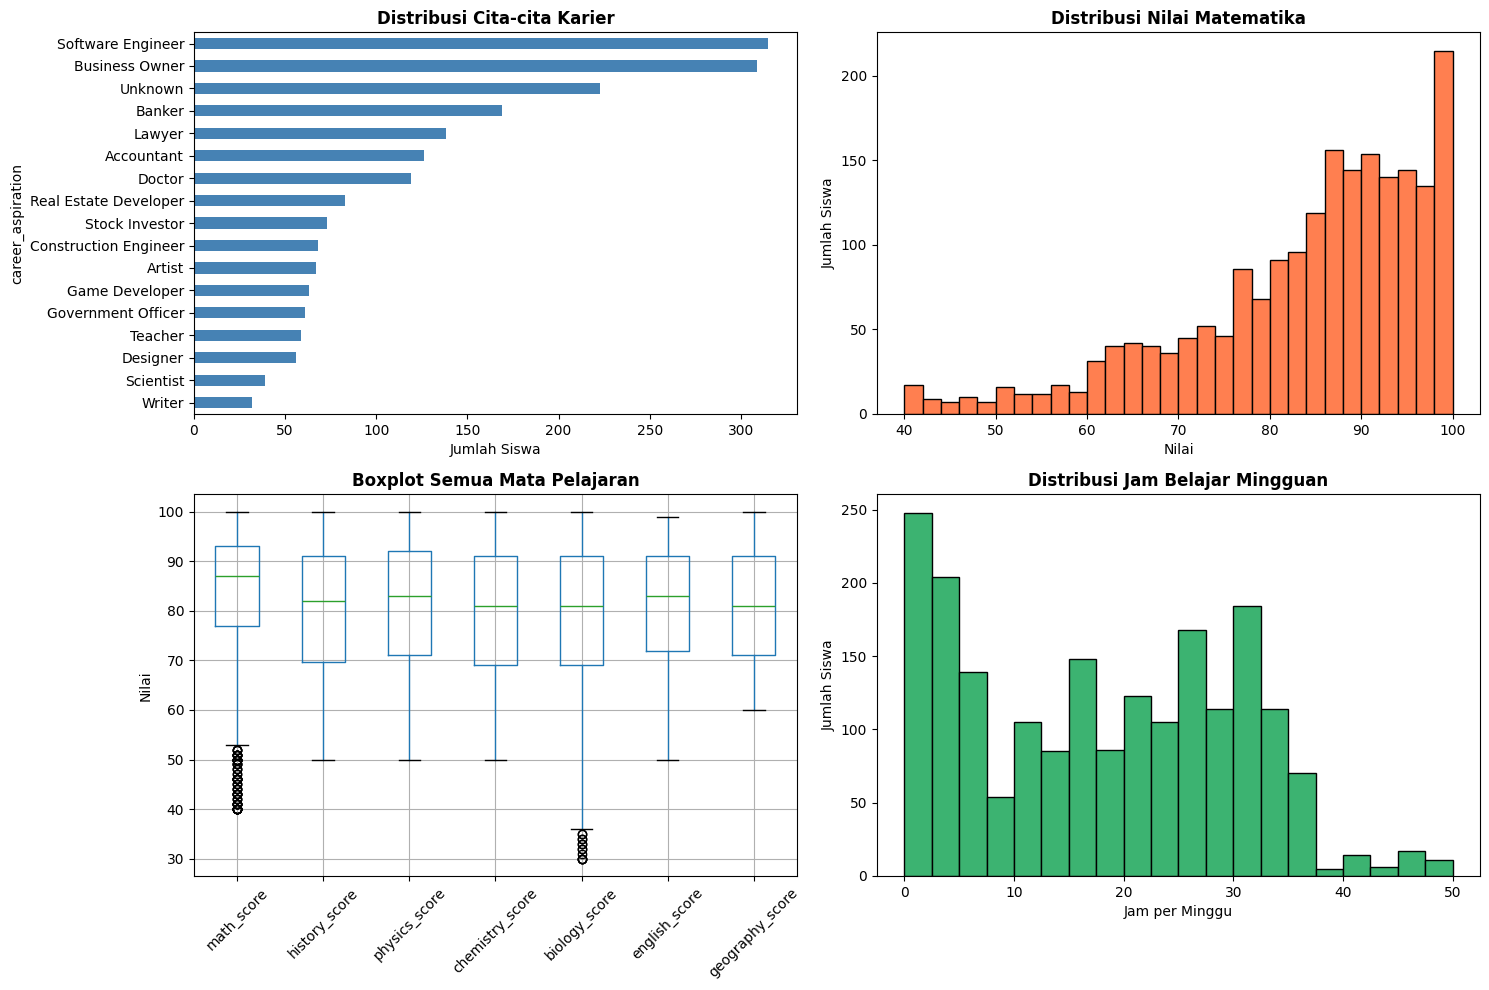

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribusi cita-cita karier (bar chart)
career_counts.plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribusi Cita-cita Karier", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Jumlah Siswa")
axes[0, 0].invert_yaxis()

# 2. Distribusi nilai matematika
axes[0, 1].hist(df["math_score"], bins=30, color="coral", edgecolor="black")
axes[0, 1].set_title("Distribusi Nilai Matematika", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Nilai")
axes[0, 1].set_ylabel("Jumlah Siswa")

# 3. Boxplot semua nilai
df[score_cols].boxplot(ax=axes[1, 0])
axes[1, 0].set_title("Boxplot Semua Mata Pelajaran", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Nilai")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Distribusi jam belajar mingguan
axes[1, 1].hist(df["weekly_self_study_hours"], bins=20, color="mediumseagreen", edgecolor="black")
axes[1, 1].set_title("Distribusi Jam Belajar Mingguan", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Jam per Minggu")
axes[1, 1].set_ylabel("Jumlah Siswa")

plt.tight_layout()
plt.savefig("eda_visualization.png", dpi=80, bbox_inches="tight")
plt.show()


-  Karier paling populer: Software Engineer, Business Owner, Banker
-  Nilai matematika cenderung tersebar dari 50-100, dengan rata-rata ~70-80
-  Semua mata pelajaran memiliki range nilai yang mirip (sekitar 50-100)
-  Sebagian besar siswa belajar 5-30 jam per minggu

### 3.6 Korelasi Antar Nilai Mata Pelajaran


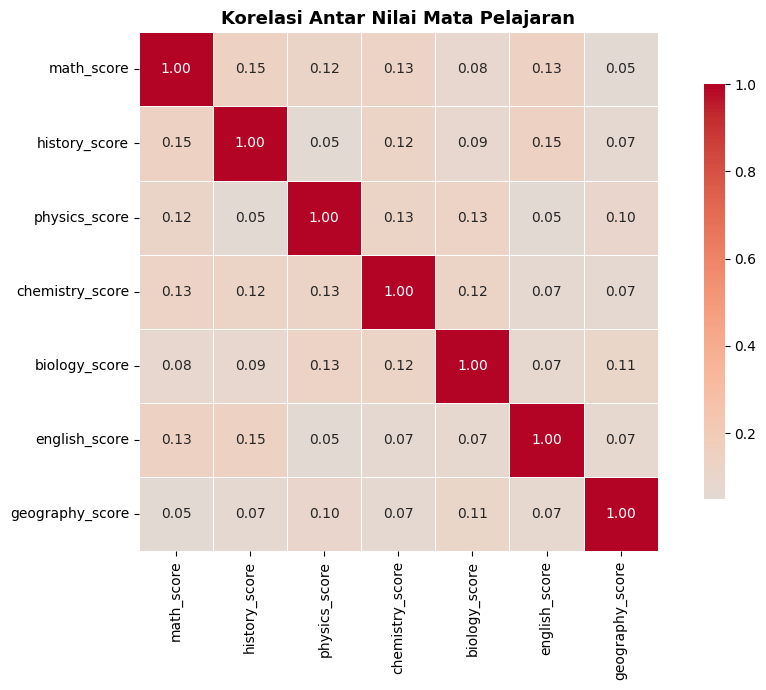

In [ ]:
plt.figure(figsize=(10, 7))
corr = df[score_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Korelasi Antar Nilai Mata Pelajaran", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=80, bbox_inches="tight")
plt.show()

Korelasi antar mata pelajaran cukup rendah (kebanyakan < 0.3). Ini berarti tiap mata pelajaran mempunyai pola sendiri-sendiri, dan tidak otomatis siswa yang unggul di satu pelajaran juga unggul di pelajaran lain.

## 4. Data Preparation


### 4.1 Hapus Siswa dengan Cita-cita "Unknown"



In [ ]:
print(f"Sebelum: {df.shape}")
df = df[df["career_aspiration"] != "Unknown"].reset_index(drop=True)
print(f"Sesudah: {df.shape}")

Sebelum: (2000, 17)
Sesudah: (1777, 17)


### 4.2 Hapus Kolom yang Tidak Relevan


In [ ]:
df_clean = df.drop(columns=["first_name", "last_name", "email"]).copy()
print("Kolom yang dipakai:", df_clean.columns.tolist())

Kolom yang dipakai: ['id', 'gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']


### 4.3 Encoding Boolean → Integer



In [ ]:
df_clean["gender"] = df_clean["gender"].map({"male": 0, "female": 1})
df_clean["part_time_job"] = df_clean["part_time_job"].astype(int)
df_clean["extracurricular_activities"] = df_clean["extracurricular_activities"].astype(int)
df_clean.head()

,id,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,0,0,3,0,27,Lawyer,73,81,93,97,63,80,87
1,2,1,0,2,0,47,Doctor,90,86,96,100,90,88,90
2,3,1,0,9,1,13,Government Officer,81,97,95,96,65,77,94
3,4,1,0,5,0,3,Artist,71,74,88,80,89,63,86
4,7,0,0,3,1,23,Software Engineer,99,96,97,73,88,76,64


### 4.4 Normalisasi Fitur (Min-Max Scaling)


In [ ]:
feature_cols = ["gender", "part_time_job", "absence_days", "extracurricular_activities",
                "weekly_self_study_hours", "math_score", "history_score", "physics_score",
                "chemistry_score", "biology_score", "english_score", "geography_score"]

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(df_clean[feature_cols])

print(f"Shape feature matrix: {features_scaled.shape}")
print(f"\nContoh hasil normalisasi (siswa pertama):")
for col, val in zip(feature_cols, np.round(features_scaled[0], 3)):
    print(f"  {col}: {val}")

Shape feature matrix: (1777, 12)

Contoh hasil normalisasi (siswa pertama):
  gender: 0.0
  part_time_job: 0.0
  absence_days: 0.3
  extracurricular_activities: 0.0
  weekly_self_study_hours: 0.54
  math_score: 0.55
  history_score: 0.62
  physics_score: 0.86
  chemistry_score: 0.94
  biology_score: 0.471
  english_score: 0.612
  geography_score: 0.675


### 4.5 Encoding Cita-cita Karier (Label Encoding)


In [ ]:
career_encoder = LabelEncoder()
df_clean["career_id"] = career_encoder.fit_transform(df_clean["career_aspiration"])

print("Mapping career → career_id:")
for i, c in enumerate(career_encoder.classes_):
    print(f"  {i}: {c}")
n_careers = df_clean["career_id"].nunique()
print(f"\nTotal karier: {n_careers}")

Mapping career → career_id:
  0: Accountant
  1: Artist
  2: Banker
  3: Business Owner
  4: Construction Engineer
  5: Designer
  6: Doctor
  7: Game Developer
  8: Government Officer
  9: Lawyer
  10: Real Estate Developer
  11: Scientist
  12: Software Engineer
  13: Stock Investor
  14: Teacher
  15: Writer

Total karier: 16


### 4.6 Membuat Data Interaksi untuk Collaborative Filtering

- Setiap siswa "menyukai" cita-citanya sendiri (label = 1)
- Setiap siswa "tidak menyukai" karier random lainnya (label = 0)

Ini disebut **negative sampling** — teknik standar di rekomendasi implicit feedback.

In [ ]:
np.random.seed(SEED)

# Positive: siswa + cita-citanya = 1
positive = df_clean[["id", "career_id"]].copy()
positive["label"] = 1.0

# Negative: 4 karier random per siswa = 0
N_NEG = 4
neg_samples = []
for _, row in df_clean.iterrows():
    sid = row["id"]
    true_cid = row["career_id"]
    # Pilih karier yang BUKAN cita-cita siswa ini
    candidates = [c for c in range(n_careers) if c != true_cid]
    neg_cids = np.random.choice(candidates, size=N_NEG, replace=False)
    for ncid in neg_cids:
        neg_samples.append({"id": sid, "career_id": ncid, "label": 0.0})

negative = pd.DataFrame(neg_samples)
interactions = pd.concat([positive, negative], ignore_index=True)
interactions = interactions.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total interaksi: {len(interactions)}")
print(f"  Positive (label=1): {(interactions['label']==1).sum()}")
print(f"  Negative (label=0): {(interactions['label']==0).sum()}")
print(f"\nRasio positive:negative = 1:{N_NEG}")

Total interaksi: 8885
  Positive (label=1): 1777
  Negative (label=0): 7108

Rasio positive:negative = 1:4


### 4.7 Encoding Student ID



In [ ]:
student_ids = df_clean["id"].unique()
student_to_idx = {s: i for i, s in enumerate(student_ids)}
idx_to_student = {i: s for s, i in student_to_idx.items()}

interactions["student_idx"] = interactions["id"].map(student_to_idx)
n_students = len(student_ids)
print(f"Total siswa unik: {n_students}")

Total siswa unik: 1777


### 4.8 Train-Test Split

80% untuk training dan 20% untuk validation.

In [ ]:
shuffled = interactions.sample(frac=1, random_state=SEED).reset_index(drop=True)
X_cf = shuffled[["student_idx", "career_id"]].values
y_cf = shuffled["label"].values

train_n = int(0.8 * len(shuffled))
X_train, X_val = X_cf[:train_n], X_cf[train_n:]
y_train, y_val = y_cf[:train_n], y_cf[train_n:]

print(f"Train size: {len(X_train)}")
print(f"Val size  : {len(X_val)}")

Train size: 7108
Val size  : 1777


## 5. Modeling Tahap 1: Content-Based Filtering

Mencari siswa-siswa yang profilnya paling mirip dengan siswa target, lalu rekomendasikan karier yang paling sering muncul di antara mereka. Menggunakan **cosine similarity** untuk ngitung kemiripan profil.



In [ ]:
# Hitung cosine similarity matrix antar siswa
sim_matrix = cosine_similarity(features_scaled)
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"\nContoh similarity siswa 0 dengan 5 siswa pertama:")
print(np.round(sim_matrix[0][:5], 4))

Similarity matrix shape: (1777, 1777)

Contoh similarity siswa 0 dengan 5 siswa pertama:
[1.     0.904  0.8024 0.7807 0.7881]


In [ ]:
# Mapping student_id ke posisi di matrix
sid_to_pos = {sid: i for i, sid in enumerate(df_clean["id"].values)}


def recommend_career_cbf(student_id, top_n=5, top_k_neighbors=50):
    if student_id not in sid_to_pos:
        return f"Siswa {student_id} tidak ditemukan."

    pos = sid_to_pos[student_id]
    sims = sim_matrix[pos].copy()
    sims[pos] = -np.inf  # exclude diri sendiri

    neighbor_idx = sims.argsort()[::-1][:top_k_neighbors]
    neighbor_careers = df_clean.iloc[neighbor_idx]["career_aspiration"].values
    neighbor_sims = sim_matrix[pos][neighbor_idx]

    # Weighted voting
    score_dict = {}
    for c, s in zip(neighbor_careers, neighbor_sims):
        score_dict[c] = score_dict.get(c, 0.0) + s

    sorted_careers = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
    return pd.DataFrame(sorted_careers[:top_n], columns=["career_aspiration", "score"])


# Demo: rekomendasi untuk siswa pertama
demo_id = df_clean["id"].iloc[0]
demo_row = df_clean[df_clean["id"] == demo_id].iloc[0]

print(f"=== Profil Siswa ID {demo_id} ===")
print(f"Cita-cita asli  : {demo_row['career_aspiration']}")
print(f"Math score      : {demo_row['math_score']}")
print(f"Physics score   : {demo_row['physics_score']}")
print(f"English score   : {demo_row['english_score']}")
print(f"Study hours/week: {demo_row['weekly_self_study_hours']}")
print()
print("Top-5 Rekomendasi Karier:")
print(recommend_career_cbf(demo_id, top_n=5).to_string(index=False))

=== Profil Siswa ID 1 ===
Cita-cita asli  : Lawyer
Math score      : 73
Physics score   : 93
English score   : 80
Study hours/week: 27

Top-5 Rekomendasi Karier:
    career_aspiration     score
               Doctor 15.544152
               Lawyer  8.768515
    Software Engineer  8.727596
Construction Engineer  4.853505
           Accountant  3.882253


## 6. Modeling Tahap 2: Collaborative Filtering (Neural Network)

Menggunakan neural network dengan **embedding layer** untuk kolom siswa dan karier. Model belajar representasi vektor masing-masing dari pola interaksi siswa-karier.

Arsitektur model:
```
[student_id] → Student Embedding (32-dim) ┐
                                          ├→ Dot Product → +bias → Sigmoid → Skor [0,1]
[career_id]  → Career Embedding (32-dim)  ┘
```

Output skor [0,1] menyatakan seberapa cocok pasangan (siswa, karier) — jika mendekati 1 berarti sangat sesuai.

In [ ]:
EMBED_DIM = 32


class CareerRecommenderNet(Model):

    def __init__(self, n_students, n_careers, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.student_emb = layers.Embedding(
            n_students, embed_dim,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
        )
        self.student_bias = layers.Embedding(n_students, 1)
        self.career_emb = layers.Embedding(
            n_careers, embed_dim,
            embeddings_initializer="he_normal",
            embeddings_regularizer=tf.keras.regularizers.l2(1e-6)
        )
        self.career_bias = layers.Embedding(n_careers, 1)

    def call(self, inputs):
        s_vec = self.student_emb(inputs[:, 0])
        s_b = self.student_bias(inputs[:, 0])
        c_vec = self.career_emb(inputs[:, 1])
        c_b = self.career_bias(inputs[:, 1])
        dot = tf.reduce_sum(s_vec * c_vec, axis=1, keepdims=True)
        x = dot + s_b + c_b
        return tf.nn.sigmoid(x)


model_cf = CareerRecommenderNet(n_students, n_careers, EMBED_DIM)
model_cf.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.003),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="acc"),
             tf.keras.metrics.AUC(name="auc")]
)

print(f"Student embedding: ({n_students}, {EMBED_DIM})")
print(f"Career embedding : ({n_careers}, {EMBED_DIM})")

Student embedding: (1777, 32)
Career embedding : (16, 32)


E0000 00:00:1778231823.574642   28553 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
# Training dengan early stopping biar nggak overfit
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=10, mode="max",
    restore_best_weights=True, verbose=1
)

history = model_cf.fit(
    x=X_train, y=y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=50,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50


112/112 - 2s - 19ms/step - acc: 0.7544 - auc: 0.5854 - loss: 0.6338 - val_acc: 0.8047 - val_auc: 0.6610 - val_loss: 0.5787


Epoch 2/50


112/112 - 1s - 8ms/step - acc: 0.8485 - auc: 0.9248 - loss: 0.4814 - val_acc: 0.8036 - val_auc: 0.6503 - val_loss: 0.5271


Epoch 3/50


...

112/112 - 0s - 3ms/step - acc: 1.0000 - auc: 1.0000 - loss: 0.0161 - val_acc: 0.7254 - val_auc: 0.6424 - val_loss: 0.5522


Epoch 11/50


112/112 - 1s - 6ms/step - acc: 1.0000 - auc: 1.0000 - loss: 0.0133 - val_acc: 0.7226 - val_auc: 0.6421 - val_loss: 0.5580


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


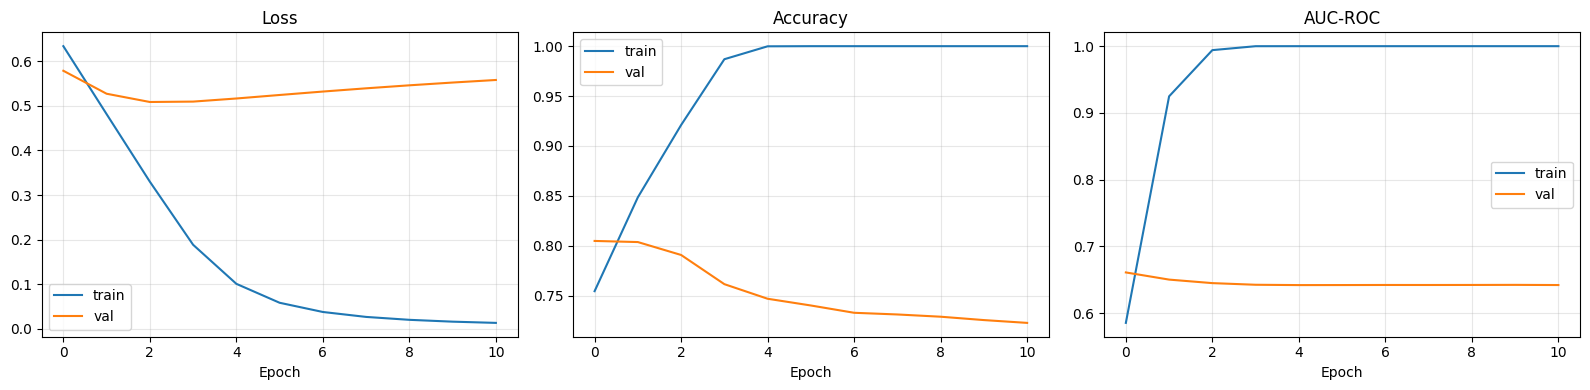

In [ ]:
# Plot learning curve
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["acc"], label="train")
axes[1].plot(history.history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history["auc"], label="train")
axes[2].plot(history.history["val_auc"], label="val")
axes[2].set_title("AUC-ROC"); axes[2].set_xlabel("Epoch"); axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=80, bbox_inches="tight")
plt.show()

## 7. Evaluation


### 7.1 Evaluasi Content-Based

In [ ]:
def evaluate_cbf_precision(top_n=5, top_k_neighbors=50):
    """Hitung Hit Rate@N untuk Content-Based."""
    n = len(df_clean)
    careers_arr = df_clean["career_aspiration"].values
    hits = 0

    for i in range(n):
        sims = sim_matrix[i].copy()
        sims[i] = -np.inf
        neighbor_idx = sims.argsort()[::-1][:top_k_neighbors]
        neighbor_careers = careers_arr[neighbor_idx]
        neighbor_sims = sim_matrix[i][neighbor_idx]

        score_dict = {}
        for c, s in zip(neighbor_careers, neighbor_sims):
            score_dict[c] = score_dict.get(c, 0.0) + s
        sorted_careers = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
        top_careers = [c for c, _ in sorted_careers[:top_n]]

        if careers_arr[i] in top_careers:
            hits += 1
    return hits / n


print("Evaluasi Content-Based Filtering:")
cbf_top1 = evaluate_cbf_precision(top_n=1, top_k_neighbors=50)
cbf_top3 = evaluate_cbf_precision(top_n=3, top_k_neighbors=50)
cbf_top5 = evaluate_cbf_precision(top_n=5, top_k_neighbors=50)
cbf_top7 = evaluate_cbf_precision(top_n=7, top_k_neighbors=50)
cbf_top10 = evaluate_cbf_precision(top_n=10, top_k_neighbors=50)

print(f"Hit Rate Top-1  : {cbf_top1:.4f}")
print(f"Hit Rate Top-3  : {cbf_top3:.4f}")
print(f"Hit Rate Top-5  : {cbf_top5:.4f}")
print(f"Hit Rate Top-7  : {cbf_top7:.4f}")
print(f"Hit Rate Top-10 : {cbf_top10:.4f}")

Evaluasi Content-Based Filtering:


Hit Rate Top-1  : 0.3624
Hit Rate Top-3  : 0.6297
Hit Rate Top-5  : 0.7676
Hit Rate Top-7  : 0.8644
Hit Rate Top-10 : 0.9460


### 7.2 Evaluasi Collaborative Filtering

In [ ]:
# Prediksi pada validation set
y_pred_val = model_cf.predict(X_val, verbose=0).flatten()
y_pred_class = (y_pred_val >= 0.5).astype(int)

cf_acc = accuracy_score(y_val, y_pred_class)
cf_prec = precision_score(y_val, y_pred_class, zero_division=0)
cf_rec = recall_score(y_val, y_pred_class, zero_division=0)
cf_f1 = f1_score(y_val, y_pred_class, zero_division=0)
cf_auc = roc_auc_score(y_val, y_pred_val)

print("Evaluasi Collaborative Filtering (klasifikasi binary):")
print(f"Akurasi  : {cf_acc:.4f}")
print(f"Precision: {cf_prec:.4f}")
print(f"Recall   : {cf_rec:.4f}")
print(f"F1-score : {cf_f1:.4f}")
print(f"AUC-ROC  : {cf_auc:.4f}")

Evaluasi Collaborative Filtering (klasifikasi binary):
Akurasi  : 0.8047
Precision: 0.3542
Recall   : 0.0511
F1-score : 0.0892
AUC-ROC  : 0.6608


In [ ]:
def evaluate_cf_hit_rate_batch(top_ns=(1, 3, 5, 7, 10)):
    """Hitung Hit Rate@N untuk semua siswa secara batch (lebih cepat)."""
    all_pairs = []
    true_careers = []
    for _, row in df_clean.iterrows():
        sid = row["id"]
        s_idx = student_to_idx[sid]
        for cid in range(n_careers):
            all_pairs.append([s_idx, cid])
        true_careers.append(row["career_id"])

    all_pairs = np.array(all_pairs)
    all_scores = model_cf.predict(all_pairs, batch_size=1024, verbose=0).flatten()

    n = len(df_clean)
    scores_matrix = all_scores.reshape(n, n_careers)

    results = {}
    for top_n in top_ns:
        hits = 0
        for i, true_cid in enumerate(true_careers):
            top_cids = scores_matrix[i].argsort()[::-1][:top_n]
            if true_cid in top_cids:
                hits += 1
        results[top_n] = hits / n
    return results


print("Hit Rate Collaborative Filtering:")
cf_hits = evaluate_cf_hit_rate_batch(top_ns=(1, 3, 5, 7, 10))
cf_top1, cf_top3, cf_top5 = cf_hits[1], cf_hits[3], cf_hits[5]
cf_top7, cf_top10 = cf_hits[7], cf_hits[10]

print(f"Hit Rate Top-1  : {cf_top1:.4f}")
print(f"Hit Rate Top-3  : {cf_top3:.4f}")
print(f"Hit Rate Top-5  : {cf_top5:.4f}")
print(f"Hit Rate Top-7  : {cf_top7:.4f}")
print(f"Hit Rate Top-10 : {cf_top10:.4f}")

Hit Rate Collaborative Filtering:


Hit Rate Top-1  : 0.2921
Hit Rate Top-3  : 0.6421
Hit Rate Top-5  : 0.8047
Hit Rate Top-7  : 0.8998
Hit Rate Top-10 : 0.9595


## 8. Demo Top-N Recommendation


In [ ]:
def recommend_career_cf(student_id, top_n=5):
    """Top-N rekomendasi karier dari Collaborative Filtering."""
    if student_id not in student_to_idx:
        return f"Siswa {student_id} tidak ditemukan."

    s_idx = student_to_idx[student_id]
    pairs = np.array([[s_idx, cid] for cid in range(n_careers)])
    scores = model_cf.predict(pairs, verbose=0).flatten()
    top_idx = scores.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "career_aspiration": career_encoder.inverse_transform(top_idx),
        "predicted_score": np.round(scores[top_idx], 4)
    })


# Demo untuk 3 siswa
for demo_id in [1, 100, 1000]:
    if demo_id not in sid_to_pos:
        continue
    row = df_clean[df_clean["id"] == demo_id].iloc[0]
    print(f"\n{'='*65}")
    print(f">>> Siswa ID {demo_id} <<<")
    print(f"{'='*65}")
    print(f"Profil:")
    print(f"  Math: {row['math_score']}, Physics: {row['physics_score']}, English: {row['english_score']}")
    print(f"  Study hours/week: {row['weekly_self_study_hours']}")
    print(f"  Cita-cita asli: {row['career_aspiration']}")
    print(f"\nRekomendasi Content-Based (Top-5):")
    print(recommend_career_cbf(demo_id, 5).to_string(index=False))
    print(f"\nRekomendasi Collaborative Filtering (Top-5):")
    print(recommend_career_cf(demo_id, 5).to_string(index=False))


>>> Siswa ID 1 <<<
Profil:
  Math: 73, Physics: 93, English: 80
  Study hours/week: 27
  Cita-cita asli: Lawyer

Rekomendasi Content-Based (Top-5):
    career_aspiration     score
               Doctor 15.544152
               Lawyer  8.768515
    Software Engineer  8.727596
Construction Engineer  4.853505
           Accountant  3.882253

Rekomendasi Collaborative Filtering (Top-5):
career_aspiration  predicted_score
Software Engineer           0.4831
   Business Owner           0.4294
           Doctor           0.4272
           Banker           0.4191
           Lawyer           0.4113

>>> Siswa ID 100 <<<
Profil:
  Math: 85, Physics: 94, English: 93
  Study hours/week: 5
  Cita-cita asli: Game Developer

Rekomendasi Content-Based (Top-5):
career_aspiration    score
           Artist 7.746612
   Game Developer 7.732737
          Teacher 5.799756
           Banker 5.777590
Software Engineer 3.877840

Rekomendasi Collaborative Filtering (Top-5):
career_aspiration  predicted_score
  

career_aspiration  predicted_score
Software Engineer           0.5127
   Business Owner           0.4819
           Lawyer           0.4466
           Banker           0.4154
           Doctor           0.4113


## 9. Ringkasan Hasil Evaluasi

In [ ]:
summary = pd.DataFrame({
    "Metrik": [
        "Content-Based: Hit Rate Top-1",
        "Content-Based: Hit Rate Top-3",
        "Content-Based: Hit Rate Top-5",
        "Content-Based: Hit Rate Top-7",
        "Content-Based: Hit Rate Top-10",
        "Collaborative Filtering: Akurasi",
        "Collaborative Filtering: Precision",
        "Collaborative Filtering: Recall",
        "Collaborative Filtering: F1-score",
        "Collaborative Filtering: AUC-ROC",
        "Collaborative Filtering: Hit Rate Top-1",
        "Collaborative Filtering: Hit Rate Top-3",
        "Collaborative Filtering: Hit Rate Top-5",
        "Collaborative Filtering: Hit Rate Top-7",
        "Collaborative Filtering: Hit Rate Top-10",
    ],
    "Nilai": [
        f"{cbf_top1:.4f}",
        f"{cbf_top3:.4f}",
        f"{cbf_top5:.4f}",
        f"{cbf_top7:.4f}",
        f"{cbf_top10:.4f}",
        f"{cf_acc:.4f}",
        f"{cf_prec:.4f}",
        f"{cf_rec:.4f}",
        f"{cf_f1:.4f}",
        f"{cf_auc:.4f}",
        f"{cf_top1:.4f}",
        f"{cf_top3:.4f}",
        f"{cf_top5:.4f}",
        f"{cf_top7:.4f}",
        f"{cf_top10:.4f}",
    ]
})
summary

,Metrik,Nilai
0,Content-Based: Hit Rate Top-1,0.3624
1,Content-Based: Hit Rate Top-3,0.6297
2,Content-Based: Hit Rate Top-5,0.7676
3,Content-Based: Hit Rate Top-7,0.8644
4,Content-Based: Hit Rate Top-10,0.9460
5,Collaborative Filtering: Akurasi,0.8047
6,Collaborative Filtering: Precision,0.3542
7,Collaborative Filtering: Recall,0.0511
8,Collaborative Filtering: F1-score,0.0892
9,Collaborative Filtering: AUC-ROC,0.6608
